# Imbalanced Text Classification - Disaster Tweets

**Course:** CS3012E Artificial Intelligence  
**Team Members:** Gowri Sankar P, 
                 Neeraj S,
                 Pankaj Kumar, 
                 Nithin R, 
                 Naveena Mariya Johnson

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("dataset.csv") 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [3]:
df['target'].value_counts()

target
0    9256
1    2114
Name: count, dtype: int64

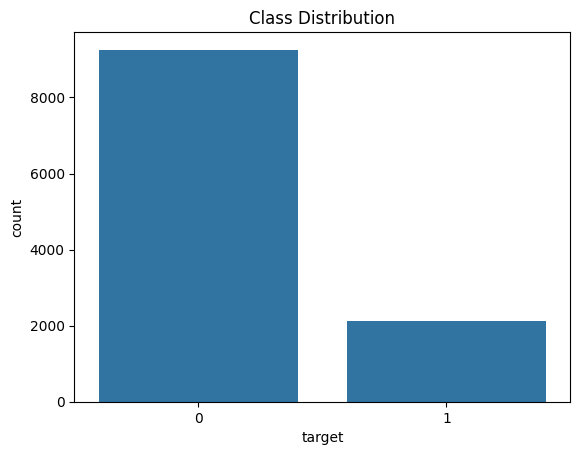

In [4]:
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

# Data pre-processing

In [5]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import emoji
import urllib.parse
import re # Regular expressions
import unicodedata

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual Wordnet (for lemmatization)

def clean_text(text):
    text = urllib.parse.unquote(text) # Fix encoding issues
    text = text.lower() 
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = emoji.demojize(text) # Convert emojis to text
    text = re.sub('\W+',' ',text) # Remove all non-word characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore') # Normalize unicode to ascii
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    cleaned_text = ' '.join(cleaned_words)

    return cleaned_text
    

df['clean_text'] = (
    df['text']
    # .fillna('') 
    .astype(str)
    # .agg(' '.join, axis=1) 
    .str.replace(r'\s+', ' ', regex=True) # Replace multiple spaces with a single space
    .str.strip() # Remove leading and trailing whitespace
    .apply(clean_text)
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nithinraj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nithinraj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/nithinraj/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
#TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['target']

In [7]:
# 70-10-20 test-validate-train split
X_train_and_valid, X_test, y_train_and_valid, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42 
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_and_valid, y_train_and_valid, test_size=0.125, stratify=y_train_and_valid, random_state=42 
)

# Part A: witout imbalance handling

### Logistical Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {
    'penalty': ['l1', 'l2'],                  # Regularization types 
    'C': [0.001, 0.01, 0.1, 1, 10],           # Regularization strengths 
    'solver': ['liblinear'],                  # 'liblinear' supports both l1 and l2
}

lr = LogisticRegression()
grid_search = GridSearchCV(lr, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# See the best parameters
print("Best Parameters:", grid_search.best_params_)

# Use the best model found
best_lr = grid_search.best_estimator_

y_probs = best_lr.predict_proba(X_test)[:, 1]

y_test_probs = best_lr.predict_proba(X_valid)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_valid, (y_test_probs >= t).astype(int)) for t in thresholds]

# Identify the threshold with the maximum F1-score
ix = np.argmax(f1_scores)
best_threshold = thresholds[ix]
print(f'Best Threshold={best_threshold:.2f}, F1-Score={f1_scores[ix]:.3f}')

y_pred = (y_probs >= best_threshold).astype(int)


Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Threshold=0.37, F1-Score=0.715


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1851
           1       0.65      0.59      0.62       423

    accuracy                           0.86      2274
   macro avg       0.78      0.76      0.77      2274
weighted avg       0.86      0.86      0.86      2274



PR-AUC: 0.7072
ROC-AUC: 0.8897


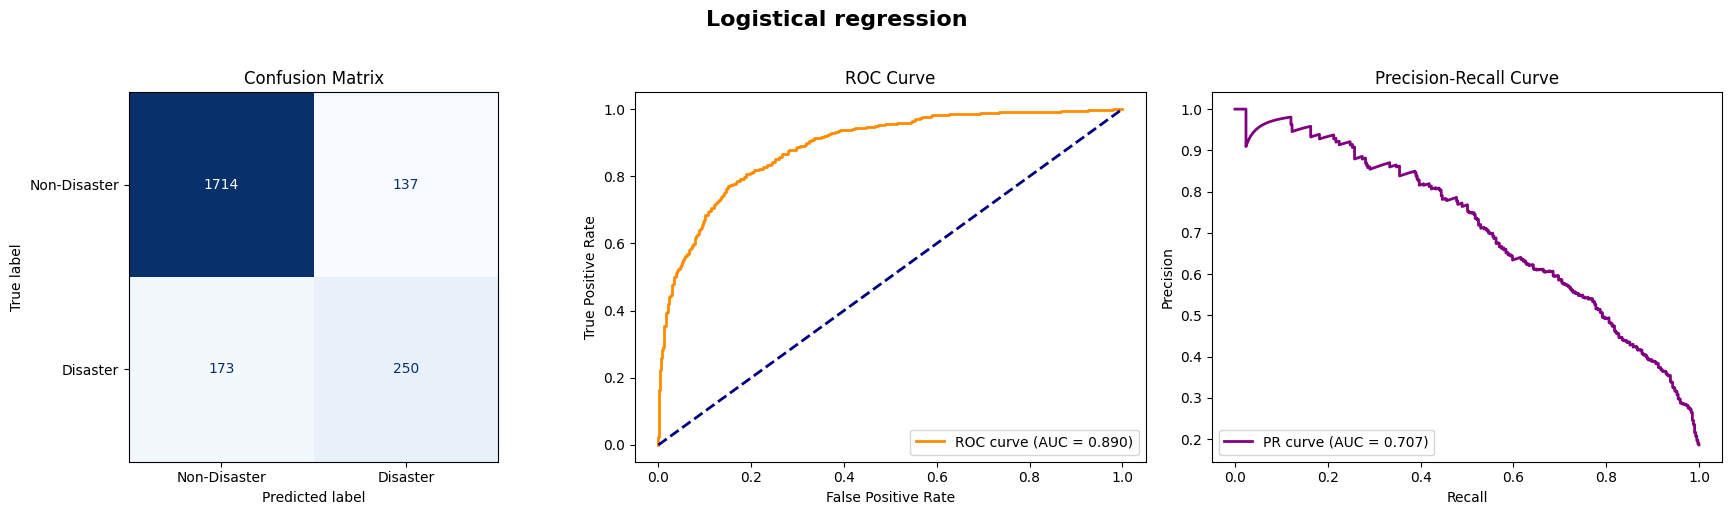

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from IPython.display import display, Markdown

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc_lr = auc(recall, precision)
roc_auc_lr = roc_auc_score(y_test, y_probs)
print(f"PR-AUC: {pr_auc_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistical regression", fontsize=16, fontweight='bold', y=1.02)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_lr:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

#### Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report

rf_param_grid = {
    'n_estimators': [100, 200],          # Number of trees 
    'max_depth': [None],         # Maximum depth 
    'min_samples_split': [2, 5],         # Min samples split 
    'min_samples_leaf': [1, 2],          # Min samples leaf 
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    rf_param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)
print("Best RF Params:", rf_grid_search.best_params_)

rf_best_estimator = rf_grid_search.best_estimator_
rf_y_probs = rf_best_estimator.predict_proba(X_test)[:, 1]

rf_y_probs_valid = rf_best_estimator.predict_proba(X_valid)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_valid, (rf_y_probs_valid >= t).astype(int)) for t in thresholds]

ix = np.argmax(f1_scores)
rf_best_threshold = thresholds[ix]
print(f'Best Threshold={rf_best_threshold:.2f}, F1-Score={f1_scores[ix]:.3f}')

y_pred_rf = (rf_y_probs >= rf_best_threshold).astype(int)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Threshold=0.36, F1-Score=0.726


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1851
           1       0.65      0.62      0.63       423

    accuracy                           0.87      2274
   macro avg       0.78      0.77      0.78      2274
weighted avg       0.86      0.87      0.87      2274



PR-AUC: 0.7191
ROC-AUC: 0.8894


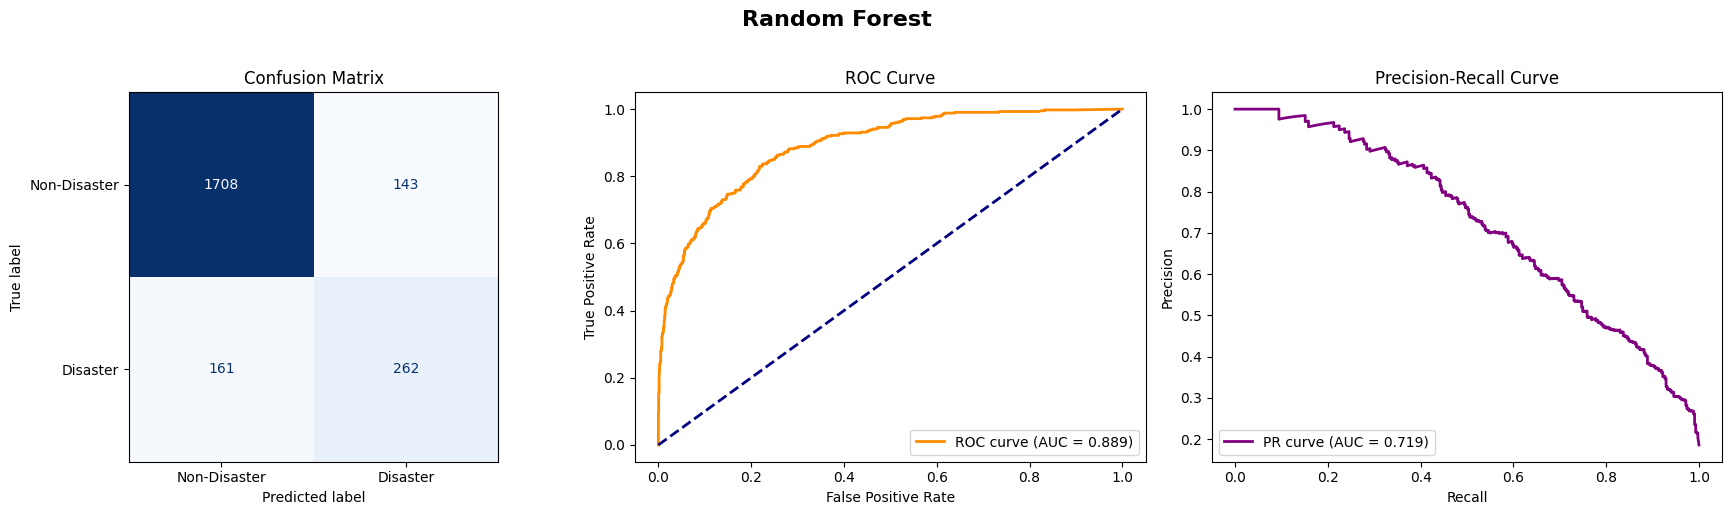

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from IPython.display import display, Markdown

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, rf_y_probs)
pr_auc_rf = auc(recall, precision)
roc_auc_rf = roc_auc_score(y_test, rf_y_probs)
print(f"PR-AUC: {pr_auc_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest", fontsize=16, fontweight='bold', y=1.02)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_y_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_rf:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

#### Neural Network

In [14]:
#NN Input → 64 → 32 → 16 → Output (sigmoid)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

I0000 00:00:1775493270.189274  129153 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775493270.976340  129153 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775493274.861847  129153 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [15]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.regularizers import l2

def create_model(activation='relu', optimizer='adam', dropout_rate=0.2, l2_reg=0.01, init='glorot_uniform'):
    model = Sequential([
        Dense(64, activation=activation, kernel_initializer=init, 
              kernel_regularizer=l2(l2_reg), input_shape=(X_train.shape[1],)),
        Dropout(dropout_rate),
        Dense(32, activation=activation, kernel_initializer=init, 
              kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(16, activation=activation, kernel_initializer=init, 
              kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid') # Fixed output layer [cite: 43]
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Wrap the model for sklearn
nn_model = KerasClassifier(model=create_model, verbose=0)

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__activation': ['leaky_relu'],
    'model__optimizer': ['adam', 'rmsprop'],
    'model__dropout_rate': [0.2],
    'model__l2_reg': [0.001, 0.01],
    'model__init': ['he_normal'],
    'batch_size': [32],
    'epochs': [20]
}

# 4. Run Grid Search
nn_grid_search = GridSearchCV(estimator=nn_model, param_grid=param_grid, cv=3, scoring='f1_macro', n_jobs=2)
grid_result = nn_grid_search.fit(X_train, y_train)

nn_best_estimator = grid_result.best_estimator_

print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")

I0000 00:00:1775493279.328499  130151 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775493279.328498  130152 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775493279.398634  130151 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775493279.398634  130152 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775493280.965202  130152 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775493280.965201  130151 

Best: 0.7638646836877866 using {'batch_size': 32, 'epochs': 20, 'model__activation': 'leaky_relu', 'model__dropout_rate': 0.2, 'model__init': 'he_normal', 'model__l2_reg': 0.001, 'model__optimizer': 'rmsprop'}


In [17]:
from sklearn.metrics import f1_score 

nn_probs = nn_best_estimator.predict_proba(X_test)[:, 1]

nn_probs_valid = nn_best_estimator.predict_proba(X_valid)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_valid, (nn_probs_valid >= t).astype(int)) for t in thresholds]

ix = np.argmax(f1_scores)
nn_best_threshold = thresholds[ix]
print(f'Best Threshold={nn_best_threshold:.2f}, F1-Score={f1_scores[ix]:.3f}')

y_pred_nn = (nn_probs >= nn_best_threshold).astype(int)

Best Threshold=0.33, F1-Score=0.654


In [18]:
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1851
           1       0.63      0.63      0.63       423

    accuracy                           0.86      2274
   macro avg       0.77      0.77      0.77      2274
weighted avg       0.86      0.86      0.86      2274



PR-AUC: 0.6822
ROC-AUC: 0.8707


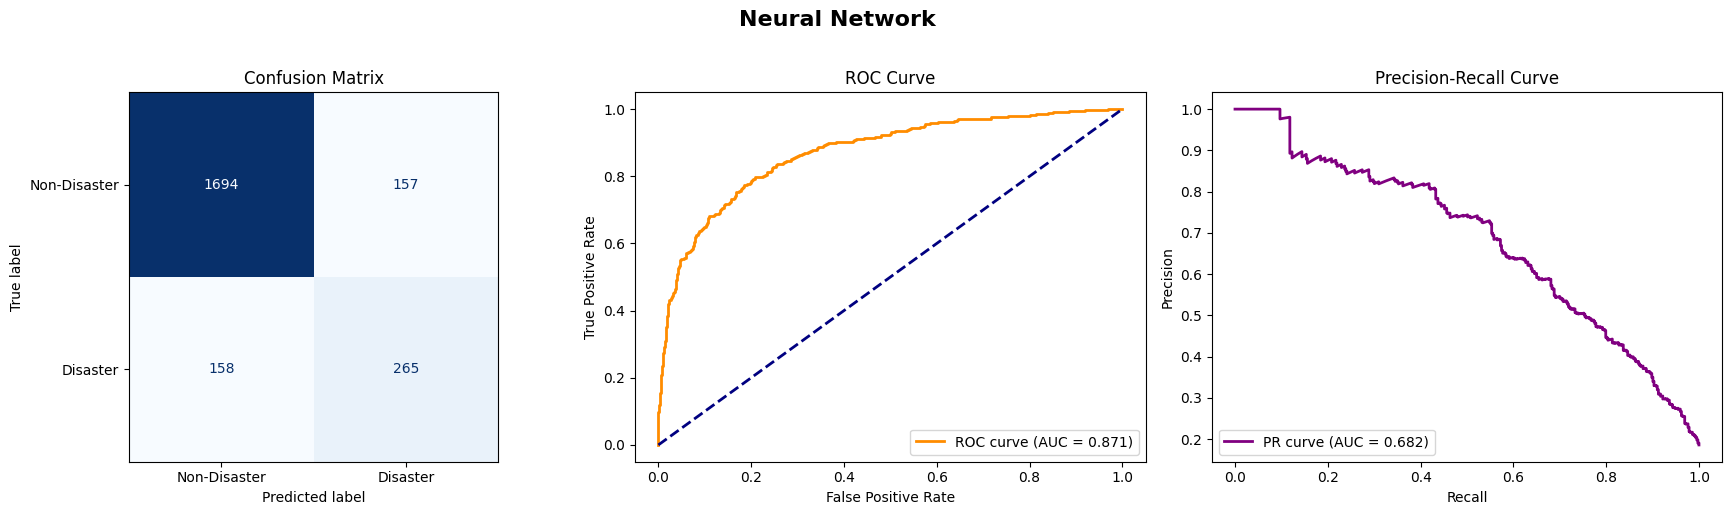

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from IPython.display import display, Markdown

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, nn_probs)
pr_auc_nn = auc(recall, precision)
roc_auc_nn = roc_auc_score(y_test, nn_probs)
print(f"PR-AUC: {pr_auc_nn:.4f}")
print(f"ROC-AUC: {roc_auc_nn:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Neural Network", fontsize=16, fontweight='bold', y=1.02)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, nn_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_nn:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_nn:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [20]:
# Access the underlying Keras model from the Scikeras wrapper
best_keras_model = nn_best_estimator.model_

# Print the architecture summary
best_keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,380 (2.46 MB)

 Trainable params: 322,689 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 322,691 (1.23 MB)

# Part B WITH imbalance handling 

## SMOTE

In [21]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [22]:
import pandas as pd
print(pd.Series(y_train_sm).value_counts())

target
0    6479
1    6479
Name: count, dtype: int64


### Logistical Regression with SMOTE

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid_lr_sm = {
    'penalty': ['l1', 'l2'],                  # Regularization types 
    'C': [0.001, 0.01, 0.1, 1, 10],           # Regularization strengths 
    'solver': ['liblinear'],                  # 'liblinear' supports both l1 and l2
}

lr_sm = LogisticRegression()
lr_sm_grid_search = GridSearchCV(lr_sm, param_grid_lr_sm, cv=5)
lr_sm_grid_search.fit(X_train_sm, y_train_sm)

print("Best Parameters:", lr_sm_grid_search.best_params_)

best_lr_sm = lr_sm_grid_search.best_estimator_

y_probs_lr_sm = best_lr_sm.predict_proba(X_test)[:, 1]

y_probs_lr_sm_valid = best_lr_sm.predict_proba(X_valid)[:, 1]
thresholds_lr_sm = np.arange(0.1, 0.9, 0.01)
f1_scores_lr_sm = [f1_score(y_valid, (y_probs_lr_sm_valid >= t).astype(int)) for t in thresholds_lr_sm]

ix_lr_sm = np.argmax(f1_scores_lr_sm)
best_threshold_lr_sm = thresholds_lr_sm[ix_lr_sm]
print(f'Best Threshold={best_threshold_lr_sm:.2f}, F1-Score={f1_scores_lr_sm[ix_lr_sm]:.3f}')

y_pred_lr_sm = (y_probs_lr_sm >= best_threshold_lr_sm).astype(int)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Threshold=0.54, F1-Score=0.702


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr_sm))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1851
           1       0.62      0.61      0.62       423

    accuracy                           0.86      2274
   macro avg       0.77      0.76      0.76      2274
weighted avg       0.86      0.86      0.86      2274



PR-AUC: 0.6988
ROC-AUC: 0.8841


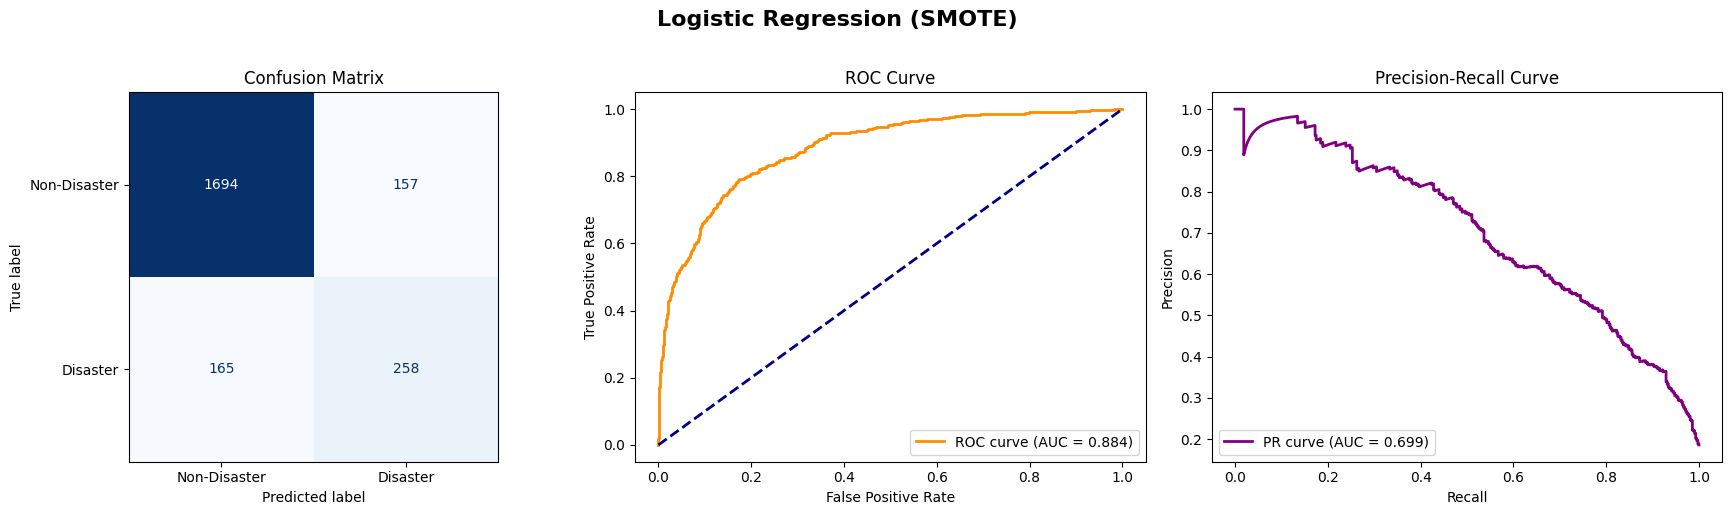

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from IPython.display import display, Markdown

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_probs_lr_sm)
pr_auc_lr_sm = auc(recall, precision)
roc_auc_lr_sm = roc_auc_score(y_test, y_probs_lr_sm)
print(f"PR-AUC: {pr_auc_lr_sm:.4f}")
print(f"ROC-AUC: {roc_auc_lr_sm:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression (SMOTE)", fontsize=16, fontweight='bold', y=1.02)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_sm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs_lr_sm)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lr_sm:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_lr_sm:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Random Forest with SMOTE

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid_rf_sm = {
    'n_estimators': [100, 200],          # Number of trees 
    'max_depth': [None],         # Maximum depth 
    'min_samples_split': [2, 5],         # Min samples split 
    'min_samples_leaf': [1, 2],          # Min samples leaf 
}

grid_search_rf_sm = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf_sm, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=6
)

grid_search_rf_sm.fit(X_train_sm, y_train_sm)
print("Best RF Params:", grid_search_rf_sm.best_params_)

best_estimator_rf_sm = grid_search_rf_sm.best_estimator_
y_probs_rf_sm = best_estimator_rf_sm.predict_proba(X_test)[:, 1]

y_probs_rf_sm_valid = best_estimator_rf_sm.predict_proba(X_valid)[:, 1]
thresholds_rf_sm = np.arange(0.1, 0.9, 0.01)
f1_scores_rf_sm = [f1_score(y_valid, (y_probs_rf_sm_valid >= t).astype(int)) for t in thresholds_rf_sm]

ix_rf_sm = np.argmax(f1_scores_rf_sm)
best_threshold_rf_sm = thresholds_rf_sm[ix_rf_sm]
print(f'Best Threshold={best_threshold_rf_sm:.2f}, F1-Score={f1_scores_rf_sm[ix_rf_sm]:.3f}')

y_pred_rf_sm = (y_probs_rf_sm >= best_threshold_rf_sm).astype(int)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Threshold=0.45, F1-Score=0.709


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf_sm))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1851
           1       0.70      0.60      0.64       423

    accuracy                           0.88      2274
   macro avg       0.80      0.77      0.78      2274
weighted avg       0.87      0.88      0.87      2274



PR-AUC: 0.7356
ROC-AUC: 0.9010


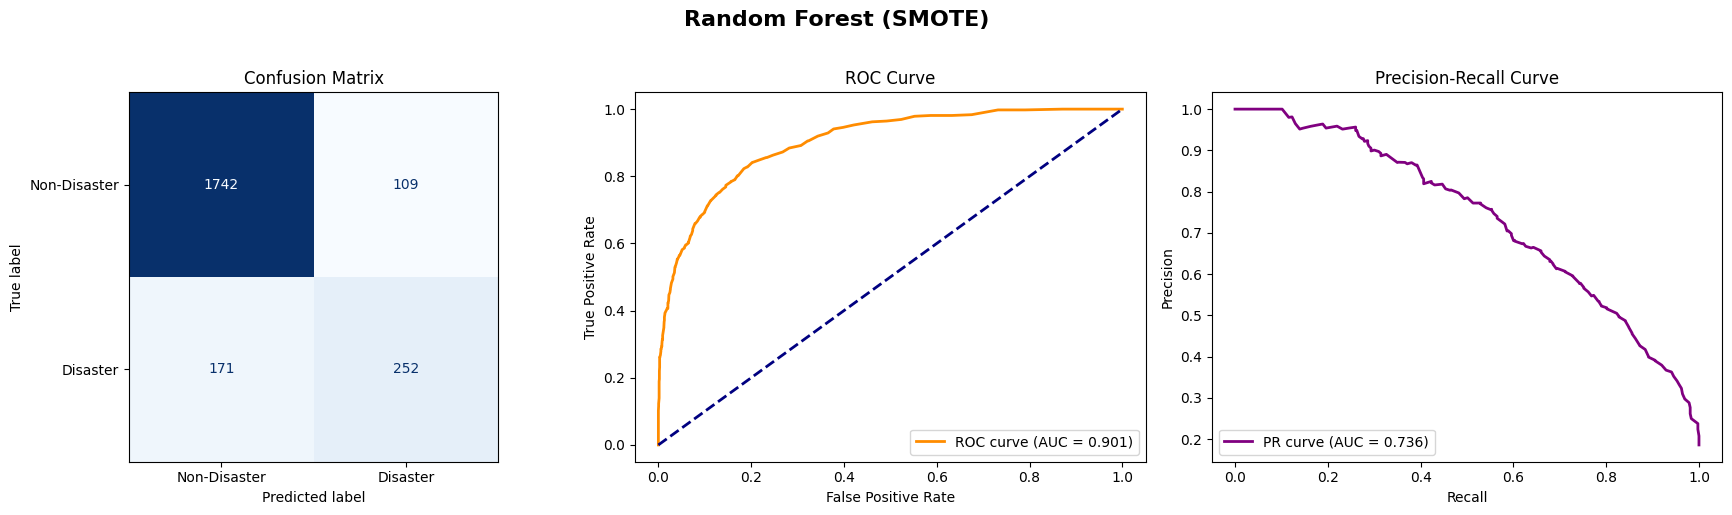

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from IPython.display import display, Markdown

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_probs_rf_sm)
pr_auc_rf_sm = auc(recall, precision)
roc_auc_rf_sm = roc_auc_score(y_test, y_probs_rf_sm)
print(f"PR-AUC: {pr_auc_rf_sm:.4f}")
print(f"ROC-AUC: {roc_auc_rf_sm:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest (SMOTE)", fontsize=16, fontweight='bold', y=1.02)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_sm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs_rf_sm)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf_sm:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_rf_sm:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Neural Network with SMOTE

In [29]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import f1_score, classification_report, roc_auc_score
import numpy as np

# 1. Define the model building function for SMOTE data
def create_nn_model_sm(activation='relu', optimizer='adam', learning_rate=0.001, 
                       l2_reg=0.001, dropout_rate=0.2, init_mode='glorot_uniform'):
    
    model = Sequential()
    
    # Input layer & Hidden Layer 1: 64 neurons (Updated for X_train_sm)
    model.add(Dense(64, activation=activation, 
                    kernel_initializer=init_mode,
                    kernel_regularizer=l2(l2_reg),
                    input_shape=(X_train_sm.shape[1],)))
    model.add(Dropout(dropout_rate)) 
    
    # Hidden Layer 2: 32 neurons
    model.add(Dense(32, activation=activation, 
                    kernel_initializer=init_mode,
                    kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    
    # Hidden Layer 3: 16 neurons
    model.add(Dense(16, activation=activation, 
                    kernel_initializer=init_mode,
                    kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate))
    
    # Output Layer (sigmoid activation)
    model.add(Dense(1, activation='sigmoid'))
    
    # Configure Optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
        
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Wrap the model for Scikit-Learn compatibility
nn_model_sm = KerasClassifier(
    model=create_nn_model_sm, 
    verbose=0
)

# 3. Define the exact same parameter grid
param_dist = {
    'model__activation': ['relu', 'leaky_relu'],
    'model__optimizer': ['adam'],
    'model__learning_rate': [0.001],
    'model__l2_reg': [1e-4],
    'model__dropout_rate': [0.3],
    'model__init_mode': ['glorot_uniform'],
    'batch_size': [64],
    'epochs': [10, 20]
}

# 4. Perform RandomizedSearchCV (n_jobs=1 is CRITICAL here)
random_search_sm = RandomizedSearchCV(
    estimator=nn_model_sm, 
    param_distributions=param_dist, 
    n_iter=10,  
    cv=3, 
    scoring='f1_macro', 
    n_jobs=2,
    random_state=42
)

# Fit using the SMOTE-balanced training data!
random_search_sm.fit(X_train_sm, y_train_sm)

print("Best Parameters (SMOTE):", random_search_sm.best_params_)

# 5. Tune Decision Threshold and Evaluate
best_nn_sm = random_search_sm.best_estimator_
nn_probs_sm = best_nn_sm.predict_proba(X_test)[:, 1]

nn_probs_sm_valid = best_nn_sm.predict_proba(X_valid)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores_sm = [f1_score(y_valid, (nn_probs_sm_valid >= t).astype(int)) for t in thresholds]

ix = np.argmax(f1_scores_sm)
nn_best_threshold_sm = thresholds[ix]
print(f'Best Threshold (SMOTE)={nn_best_threshold_sm:.2f}, F1-Score={f1_scores_sm[ix]:.3f}')

# Generate final predictions
y_pred_nn_sm = (nn_probs_sm >= nn_best_threshold_sm).astype(int)

# 6. Final Evaluation Metrics for Part B
print("\n--- SMOTE Neural Network Results ---")
print(classification_report(y_test, y_pred_nn_sm))
print("ROC-AUC (SMOTE):", roc_auc_score(y_test, nn_probs_sm))

I0000 00:00:1775494305.161575  138864 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775494305.161576  138863 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775494305.373386  138863 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775494305.373387  138864 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775494307.268956  138863 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775494307.268956  138864 

Best Parameters (SMOTE): {'model__optimizer': 'adam', 'model__learning_rate': 0.001, 'model__l2_reg': 0.0001, 'model__init_mode': 'glorot_uniform', 'model__dropout_rate': 0.3, 'model__activation': 'relu', 'epochs': 10, 'batch_size': 64}
Best Threshold (SMOTE)=0.88, F1-Score=0.680

--- SMOTE Neural Network Results ---
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1851
           1       0.69      0.55      0.61       423

    accuracy                           0.87      2274
   macro avg       0.80      0.75      0.77      2274
weighted avg       0.86      0.87      0.87      2274

ROC-AUC (SMOTE): 0.8685133459263602


PR-AUC (SMOTE): 0.6855


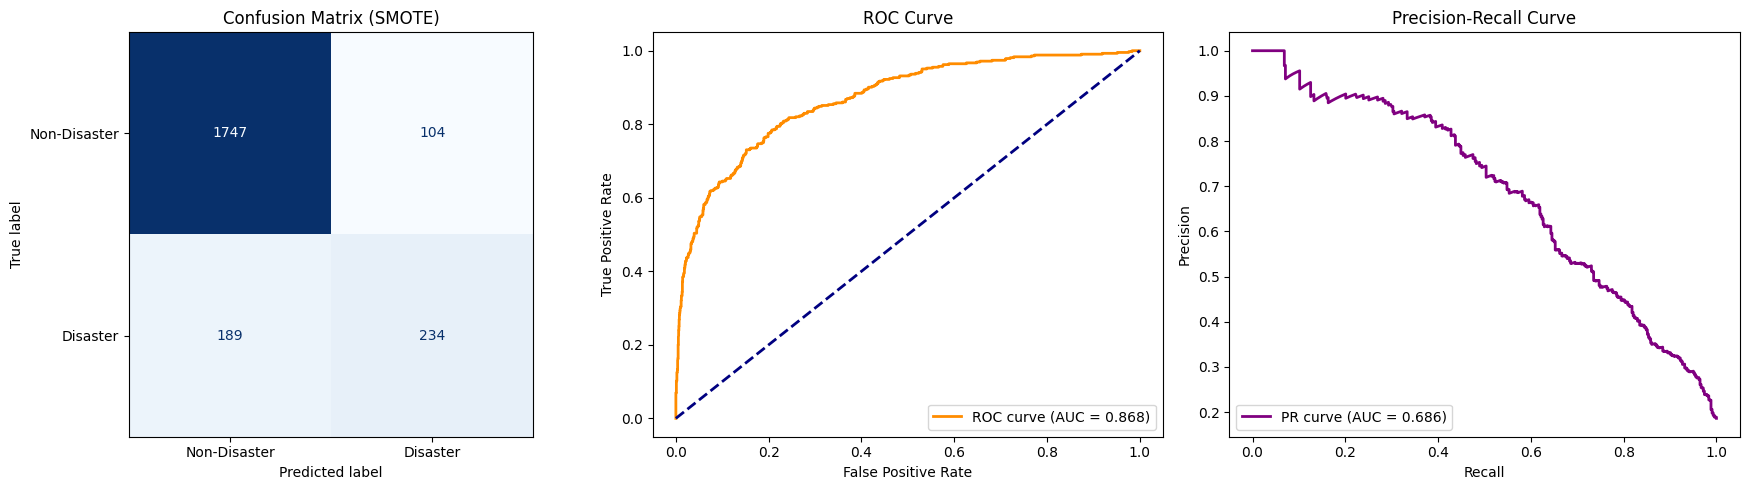

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, nn_probs_sm)
pr_auc_sm = auc(recall, precision)
print(f"PR-AUC (SMOTE): {pr_auc_sm:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn_sm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (SMOTE)')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, nn_probs_sm)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {0.868:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_sm:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [31]:
y_prob_nn_sm = best_nn_sm.predict(X_test)
y_pred_nn_sm = (y_prob_nn_sm > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn_sm))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1851
           1       0.66      0.62      0.64       423

    accuracy                           0.87      2274
   macro avg       0.79      0.77      0.78      2274
weighted avg       0.87      0.87      0.87      2274



## Class Weights

### Logistical Regression with Class Weights

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {
    'penalty': ['l1', 'l2'],                  # Regularization types 
    'C': [0.001, 0.01, 0.1, 1, 10],           # Regularization strengths 
    'solver': ['liblinear'],                  # 'liblinear' supports both l1 and l2
}

lr_w = LogisticRegression(class_weight='balanced')
grid_search_lr_w = GridSearchCV(lr_w, param_grid, cv=5)
grid_search_lr_w.fit(X_train, y_train)

print("Best LR Params:", grid_search_lr_w.best_params_)

best_estimator_lr_w = grid_search_lr_w.best_estimator_
y_probs_lr_w = best_estimator_lr_w.predict_proba(X_test)[:, 1]

y_probs_lr_w_valid = best_estimator_lr_w.predict_proba(X_valid)[:, 1]
thresholds_lr_w = np.arange(0.1, 0.9, 0.01)
f1_scores_lr_w = [f1_score(y_valid, (y_probs_lr_w_valid >= t).astype(int)) for t in thresholds_lr_w]

ix_lr_w = np.argmax(f1_scores_lr_w)
best_threshold_lr_w = thresholds_lr_w[ix_lr_w]
print(f'Best Threshold={best_threshold_lr_w:.2f}, F1-Score={f1_scores_lr_w[ix_lr_w]:.3f}')

y_pred_lr_w = (y_probs_lr_w >= best_threshold_lr_w).astype(int)

Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Threshold=0.61, F1-Score=0.703


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr_w))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1851
           1       0.63      0.59      0.61       423

    accuracy                           0.86      2274
   macro avg       0.77      0.76      0.76      2274
weighted avg       0.86      0.86      0.86      2274



PR-AUC: 0.6969
ROC-AUC: 0.8866


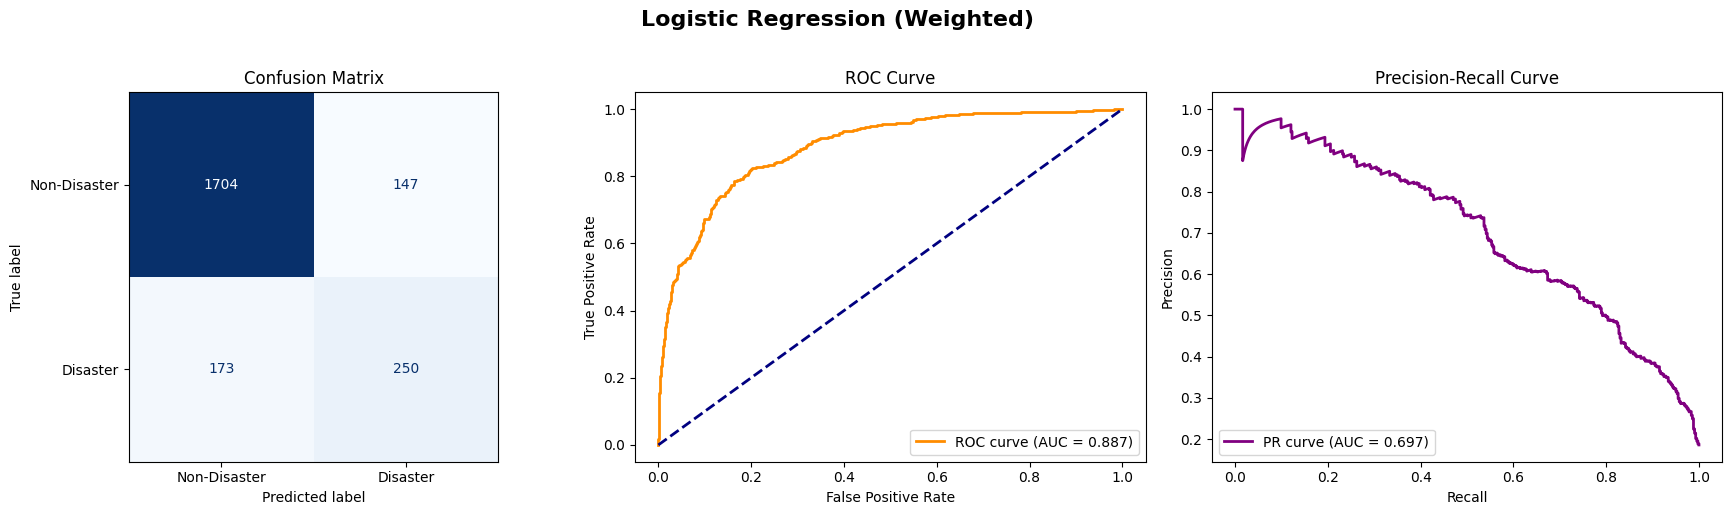

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from IPython.display import display, Markdown

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_probs_lr_w)
pr_auc_lr_w = auc(recall, precision)
roc_auc_lr_w = roc_auc_score(y_test, y_probs_lr_w)
print(f"PR-AUC: {pr_auc_lr_w:.4f}")
print(f"ROC-AUC: {roc_auc_lr_w:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression (Weighted)", fontsize=16, fontweight='bold', y=1.02)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_w)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs_lr_w)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lr_w:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_lr_w:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Random Forest with Weights

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

rf_param_grid = {
    'n_estimators': [200],          # Number of trees 
    'max_depth': [None],         # Maximum depth 
    'min_samples_split': [2, 5],         # Min samples split 
    'min_samples_leaf': [1, 2],          # Min samples leaf 
}

rf_w = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search_rf_w = GridSearchCV(rf_w, rf_param_grid, cv=3, scoring='f1_macro', n_jobs=6)

grid_search_rf_w.fit(X_train, y_train)
print("Best RF Params:", grid_search_rf_w.best_params_)

rf_best_estimator_w = grid_search_rf_w.best_estimator_
y_probs_rf_w = rf_best_estimator_w.predict_proba(X_test)[:, 1]

y_probs_rf_w_valid = rf_best_estimator_w.predict_proba(X_valid)[:, 1]
thresholds_rf_w = np.arange(0.1, 0.9, 0.01)
f1_scores_rf_w = [f1_score(y_valid, (y_probs_rf_w_valid >= t).astype(int)) for t in thresholds_rf_w]

ix_rf_w = np.argmax(f1_scores_rf_w)
best_threshold_rf_w = thresholds_rf_w[ix_rf_w]
print(f'Best Threshold={best_threshold_rf_w:.2f}, F1-Score={f1_scores_rf_w[ix_rf_w]:.3f}')

y_pred_rf_w = (y_probs_rf_w >= best_threshold_rf_w).astype(int)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Threshold=0.48, F1-Score=0.703


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr_w))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1851
           1       0.63      0.59      0.61       423

    accuracy                           0.86      2274
   macro avg       0.77      0.76      0.76      2274
weighted avg       0.86      0.86      0.86      2274



PR-AUC: 0.7136
ROC-AUC: 0.8978


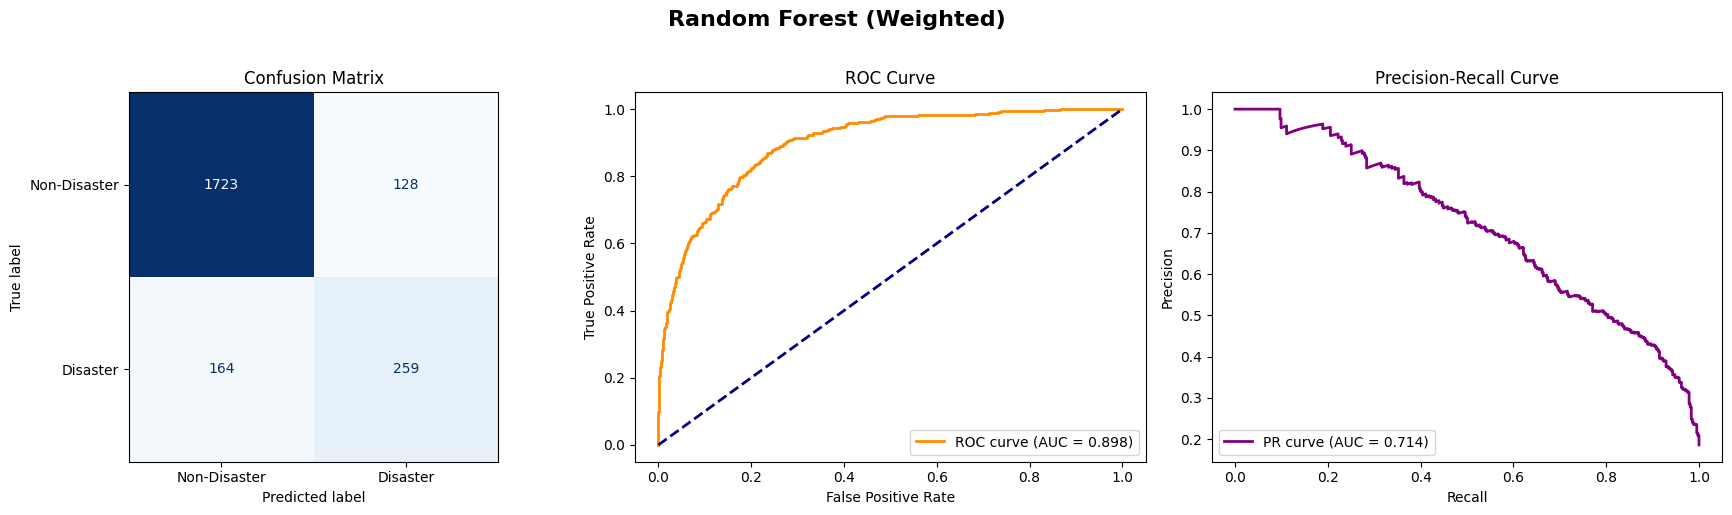

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from IPython.display import display, Markdown

# 1. Calculate PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_probs_rf_w)
pr_auc_rf_w = auc(recall, precision)
roc_auc_rf_w = roc_auc_score(y_test, y_probs_rf_w)
print(f"PR-AUC: {pr_auc_rf_w:.4f}")
print(f"ROC-AUC: {roc_auc_rf_w:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest (Weighted)", fontsize=16, fontweight='bold', y=1.02)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_w)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs_rf_w)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf_w:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# 4. Precision-Recall Curve
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_rf_w:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Neural Network with Weights

In [38]:
#NN with class weights
class_weights = {0: 1, 1: 4}  # because imbalance ~4:1


Applying Class Weights: {0: np.float64(0.6142151566599784), 1: np.float64(2.6888513513513512)}

Training final optimized model...
Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5382 - loss: 0.8843 - val_accuracy: 0.6935 - val_loss: 0.8624
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6468 - loss: 0.8474 - val_accuracy: 0.7739 - val_loss: 0.8351
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7233 - loss: 0.8186 - val_accuracy: 0.8342 - val_loss: 0.8040
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8048 - loss: 0.7829 - val_accuracy: 0.8317 - val_loss: 0.7715
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8473 - loss: 0.7383 - val_accuracy: 0.8467 - val_loss: 0.7221
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8787 - loss: 0.6819 - val_accuracy: 0.8518 - val_loss: 0.6633
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8892 - loss: 0.6169 - val_accuracy: 

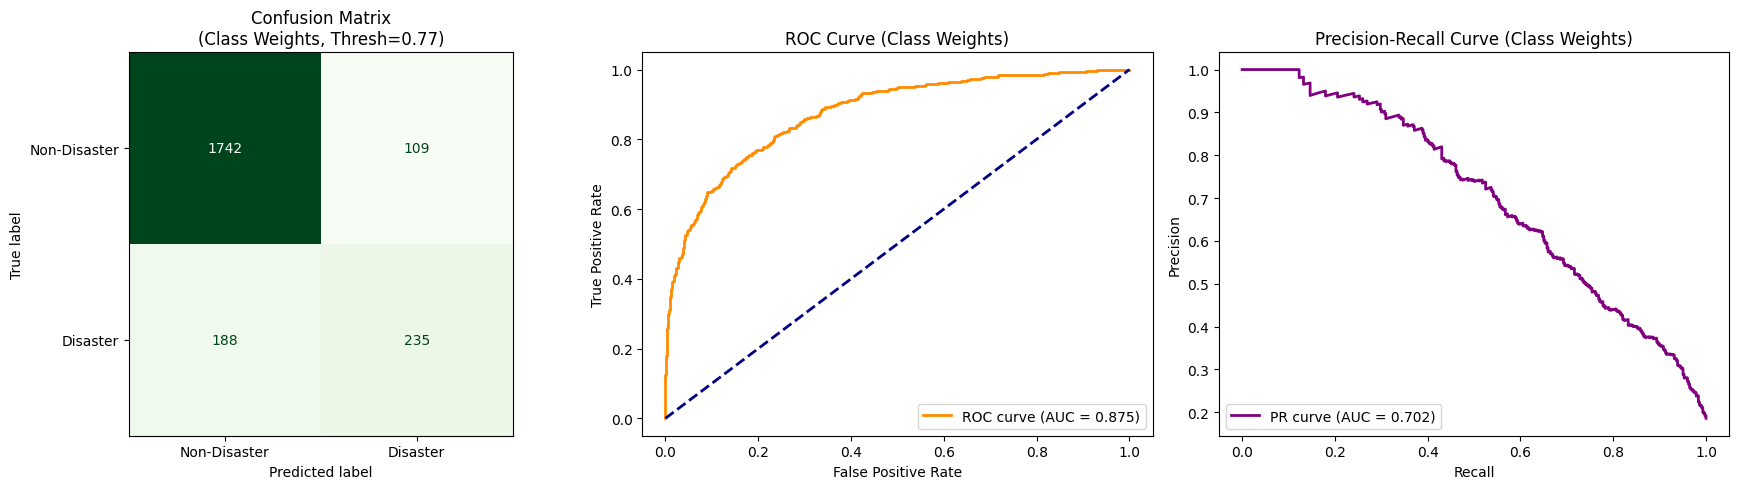

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculate Class Weights dynamically
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights_array))
print("Applying Class Weights:", class_weights)

# 2. Build the model directly with your BEST parameters from yesterday
best_nn_w = Sequential([
    Dense(64, activation='elu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(32, activation='elu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(16, activation='elu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Best Optimizer & Learning Rate
best_nn_w.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train the model (Using validation_split instead of a manual X_valid set)
print("\nTraining final optimized model...")
history = best_nn_w.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    validation_split=0.1, 
    verbose=1
)

# 4. Generate Predictions using your BEST threshold (0.77)
y_prob_nn_w = best_nn_w.predict(X_test).ravel() # .ravel() flattens the array
nn_best_threshold_w = 0.77
y_pred_nn_w = (y_prob_nn_w >= nn_best_threshold_w).astype(int)

# 5. Final Evaluation Metrics
print(f"\n--- Class Weighted Neural Network Results (Threshold: {nn_best_threshold_w}) ---")
print(classification_report(y_test, y_pred_nn_w))
roc_auc_val_w = roc_auc_score(y_test, y_prob_nn_w)
print("ROC-AUC (Class Weights):", roc_auc_val_w)

# 6. Plot the 3 Required Graphs
precision_w, recall_w, _ = precision_recall_curve(y_test, y_prob_nn_w)
pr_auc_w = auc(recall_w, precision_w)
print(f"PR-AUC (Class Weights): {pr_auc_w:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
cm_w = confusion_matrix(y_test, y_pred_nn_w)
disp_w = ConfusionMatrixDisplay(confusion_matrix=cm_w, display_labels=['Non-Disaster', 'Disaster'])
disp_w.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n(Class Weights, Thresh={nn_best_threshold_w})')

# Plot 2: ROC Curve
fpr_w, tpr_w, _ = roc_curve(y_test, y_prob_nn_w)
axes[1].plot(fpr_w, tpr_w, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val_w:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Class Weights)')
axes[1].legend(loc="lower right")

# Plot 3: Precision-Recall Curve
axes[2].plot(recall_w, precision_w, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_w:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve (Class Weights)')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [40]:
# Predict using your dynamically tuned threshold instead of 0.5
y_pred_nn_w = (y_prob_nn_w >= nn_best_threshold_w).astype(int)

# Print the final metrics for the report
print(f"\n--- Class Weighted Neural Network Results (Threshold: {nn_best_threshold_w:.2f}) ---")
print(classification_report(y_test, y_pred_nn_w))
print("ROC-AUC (Class Weights):", roc_auc_score(y_test, y_prob_nn_w))


--- Class Weighted Neural Network Results (Threshold: 0.77) ---
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1851
           1       0.68      0.56      0.61       423

    accuracy                           0.87      2274
   macro avg       0.79      0.75      0.77      2274
weighted avg       0.86      0.87      0.86      2274

ROC-AUC (Class Weights): 0.8749854720405429


PR-AUC (Class Weights): 0.7019


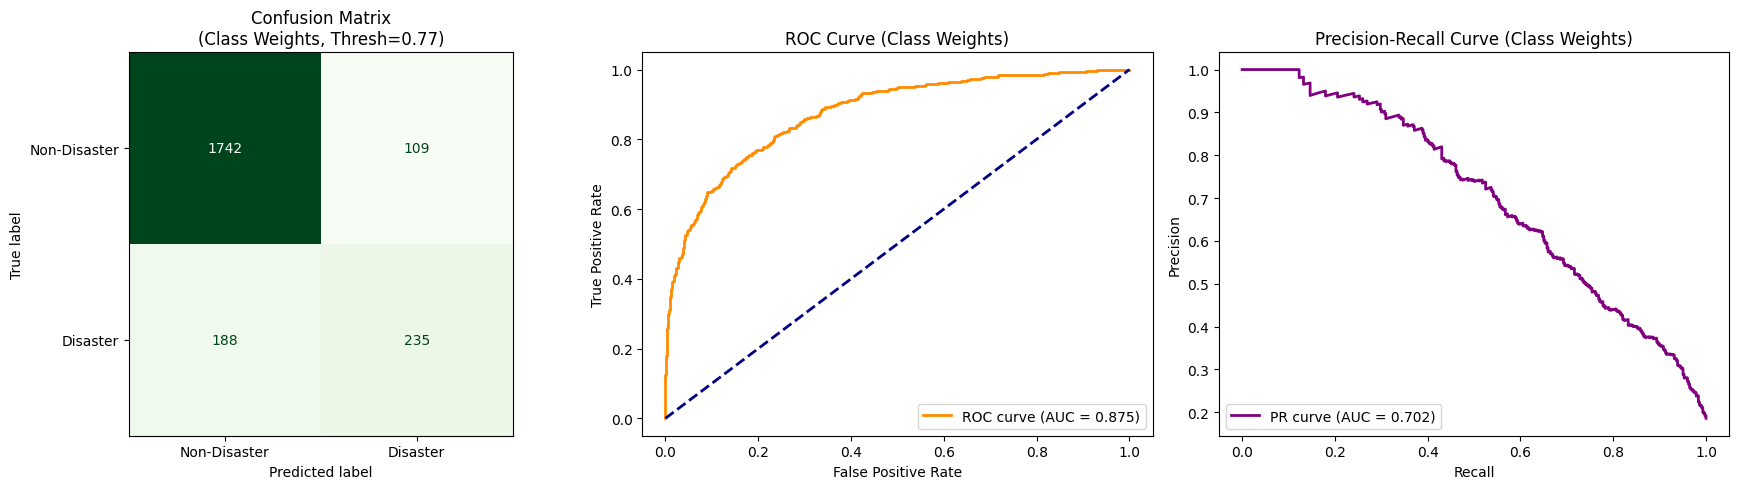

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc

# 1. Calculate PR-AUC for the weighted model
precision_w, recall_w, _ = precision_recall_curve(y_test, y_prob_nn_w)
pr_auc_w = auc(recall_w, precision_w)
print(f"PR-AUC (Class Weights): {pr_auc_w:.4f}")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
cm_w = confusion_matrix(y_test, y_pred_nn_w)
disp_w = ConfusionMatrixDisplay(confusion_matrix=cm_w, display_labels=['Non-Disaster', 'Disaster'])
disp_w.plot(ax=axes[0], cmap='Greens', colorbar=False) # Changed color to visually separate from SMOTE
axes[0].set_title(f'Confusion Matrix\n(Class Weights, Thresh={nn_best_threshold_w:.2f})')

# Plot 2: ROC Curve
fpr_w, tpr_w, _ = roc_curve(y_test, y_prob_nn_w)
roc_auc_val_w = roc_auc_score(y_test, y_prob_nn_w)
axes[1].plot(fpr_w, tpr_w, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val_w:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Class Weights)')
axes[1].legend(loc="lower right")

# Plot 3: Precision-Recall Curve
axes[2].plot(recall_w, precision_w, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc_w:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve (Class Weights)')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

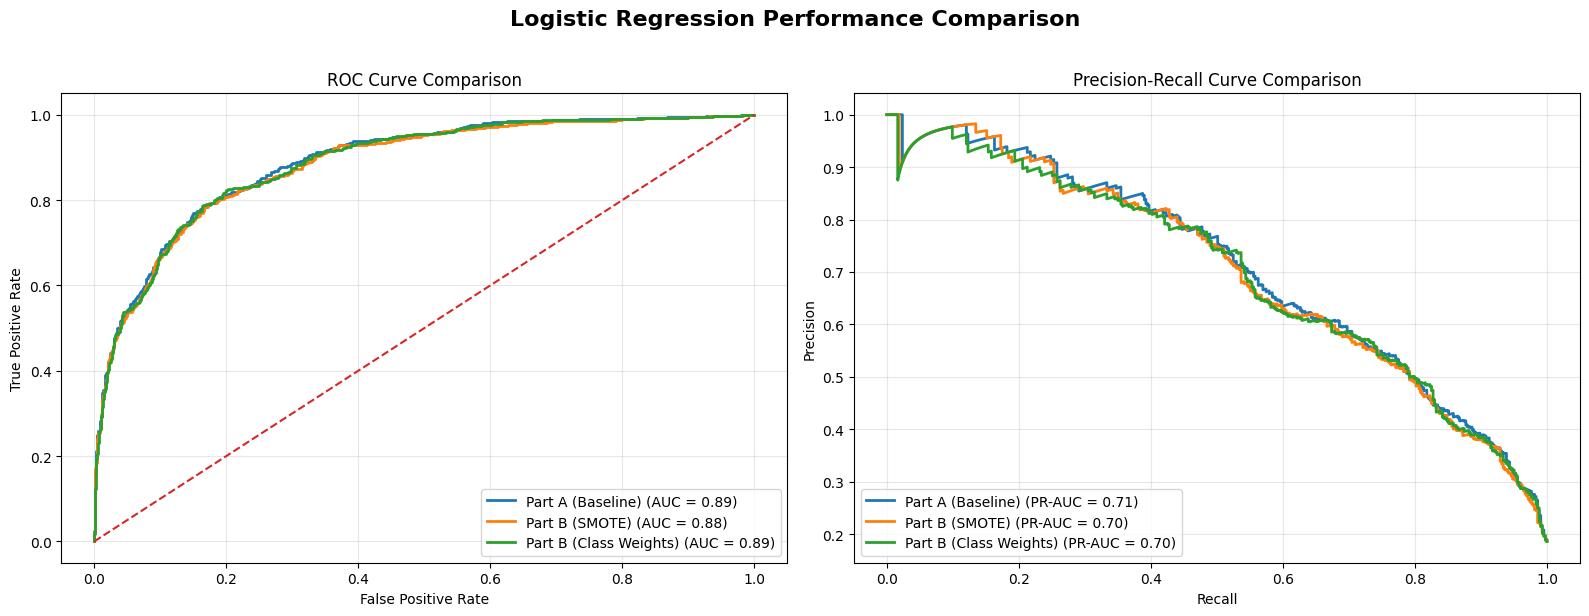

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Data for Logistic Regression
models_lr = {
    'Part A (Baseline)': y_probs,
    'Part B (SMOTE)': y_probs_lr_sm,
    'Part B (Class Weights)': y_probs_lr_w
}

# Create one figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Logistic Regression Performance Comparison", fontsize=16, fontweight='bold', y=1.02)

# --- ROC Curve ---
for label, probs in models_lr.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# --- PR Curve ---
for label, probs in models_lr.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, lw=2, label=f'{label} (PR-AUC = {pr_auc:.2f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

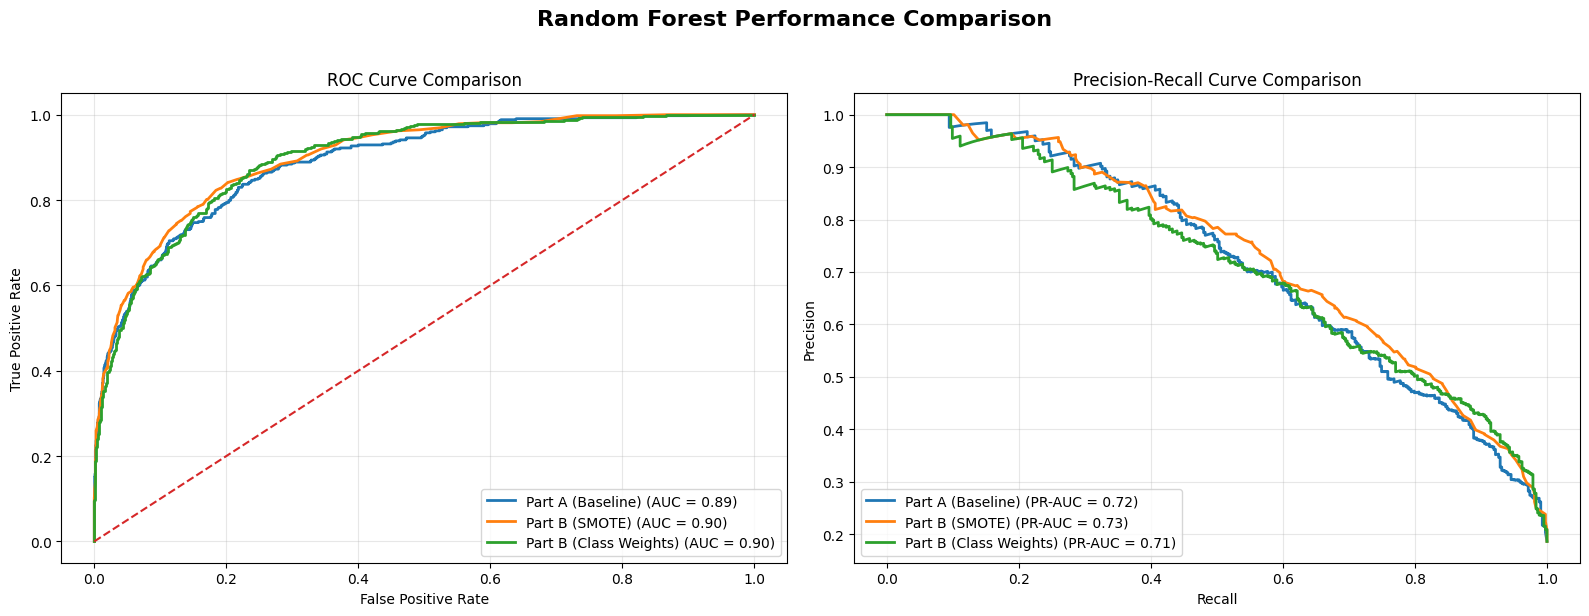

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Data for Random Forest
models_rf = {
    'Part A (Baseline)': rf_y_probs,
    'Part B (SMOTE)': y_probs_rf_sm,
    'Part B (Class Weights)': y_probs_rf_w
}

# Create one figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Random Forest Performance Comparison", fontsize=16, fontweight='bold', y=1.02)

# --- ROC Curve ---
for label, probs in models_rf.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# --- PR Curve ---
for label, probs in models_rf.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, lw=2, label=f'{label} (PR-AUC = {pr_auc:.2f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

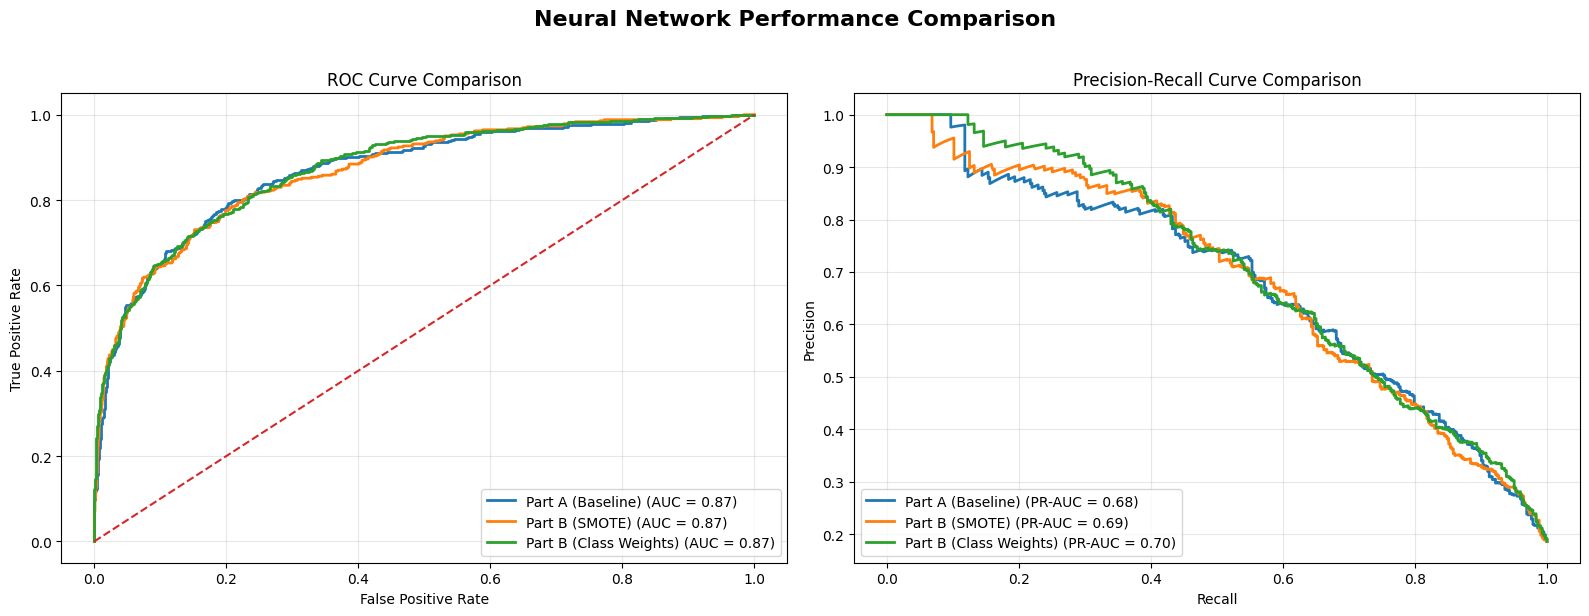

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Data for Neural Network
models_nn = {
    'Part A (Baseline)': nn_probs,
    'Part B (SMOTE)': nn_probs_sm,
    'Part B (Class Weights)': y_prob_nn_w
}

# Create one figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Neural Network Performance Comparison", fontsize=16, fontweight='bold', y=1.02)

# --- ROC Curve ---
for label, probs in models_nn.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# --- PR Curve ---
for label, probs in models_nn.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, lw=2, label=f'{label} (PR-AUC = {pr_auc:.2f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()